In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from wordcloud import WordCloud
from collections import Counter
import random
np.random.seed(42)
random.seed(42)
import services.utils as ut

In [36]:
data_df = ut.load_data('customer_support_tickets.csv')
if data_df is not None:
    print("Data loaded successfully")
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

In [37]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [38]:
for column in data_df.columns:
    print(f"{column}: {data_df[column].isnull().sum()} null values")

Ticket ID: 0 null values
Customer Name: 0 null values
Customer Email: 0 null values
Customer Age: 0 null values
Customer Gender: 0 null values
Product Purchased: 0 null values
Date of Purchase: 0 null values
Ticket Type: 0 null values
Ticket Subject: 0 null values
Ticket Description: 0 null values
Ticket Status: 0 null values
Resolution: 5700 null values
Ticket Priority: 0 null values
Ticket Channel: 0 null values
First Response Time: 2819 null values
Time to Resolution: 5700 null values
Customer Satisfaction Rating: 5700 null values


## Univariant Analysis

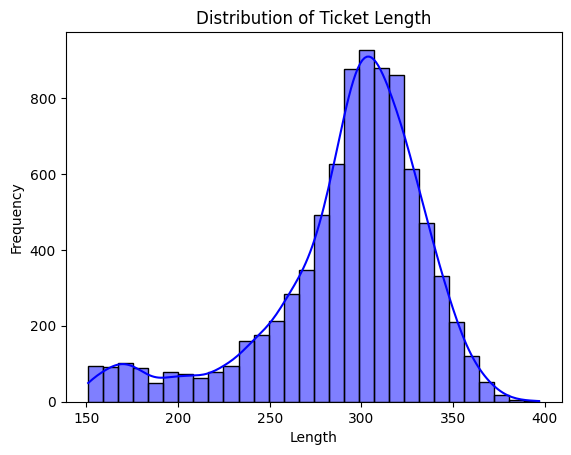

In [39]:
data_df['text_length'] = data_df['Ticket Description'].astype(str).apply(len)

sns.histplot(data_df['text_length'], bins=30, kde=True, color='blue')
plt.title("Distribution of Ticket Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

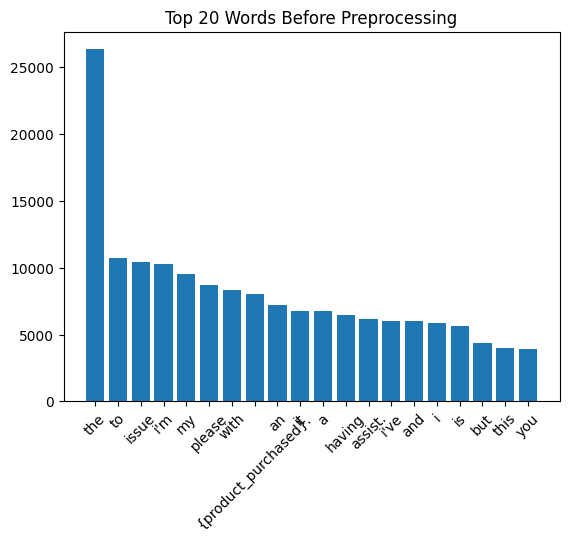

In [40]:
text_data = data_df['Ticket Description'].astype(str)

all_words = " ".join(text_data).lower().split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words Before Preprocessing")
plt.show()

In [41]:
unique_words = set(all_words)
print("Vocabulary size:", len(unique_words))

Vocabulary size: 13826


<Axes: xlabel='Customer Satisfaction Rating'>

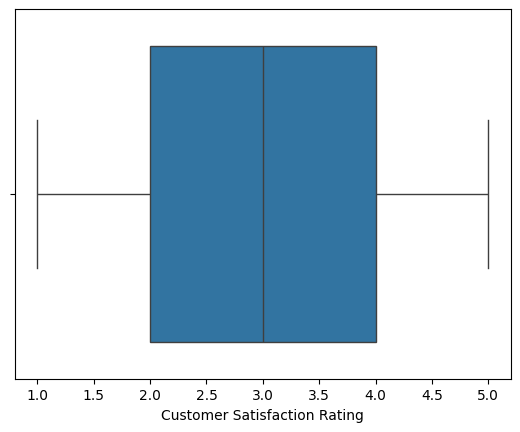

In [42]:
sns.boxplot(x=data_df['Customer Satisfaction Rating'])

<Axes: xlabel='Customer Age'>

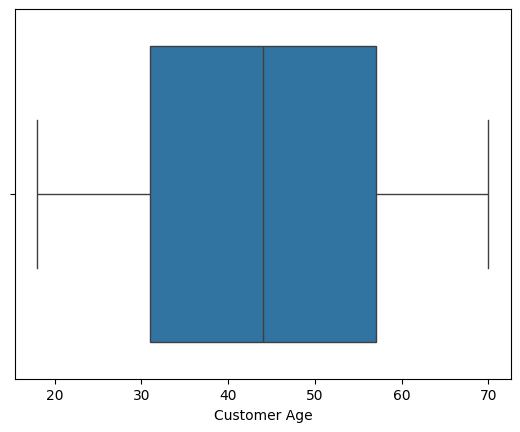

In [43]:
sns.boxplot(x=data_df['Customer Age'])

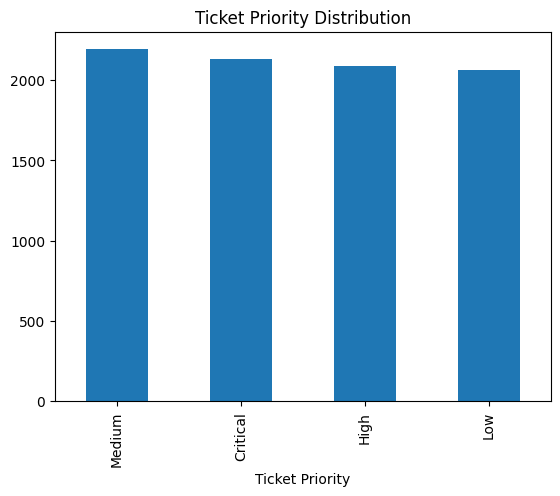

In [44]:
data_df['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority Distribution")
plt.show()

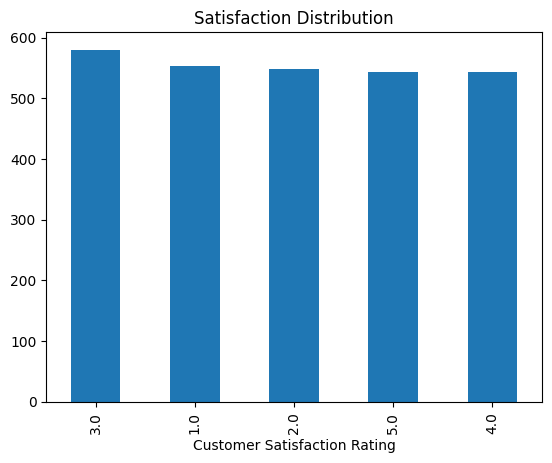

In [45]:
data_df['Customer Satisfaction Rating'].value_counts().plot(kind='bar')
plt.title("Satisfaction Distribution")
plt.show()

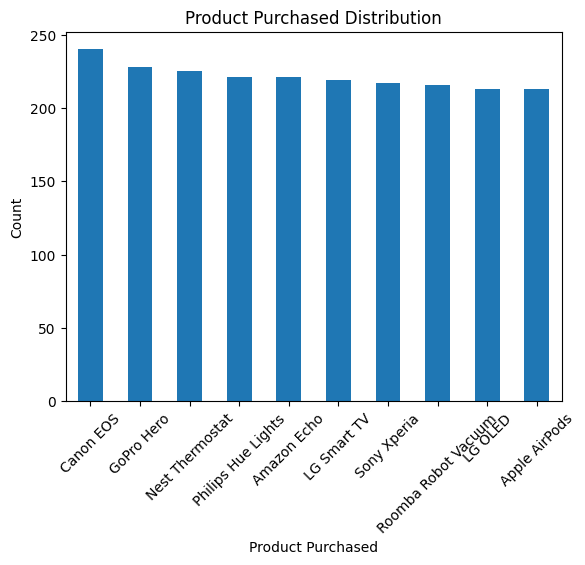

In [46]:
data_df['Product Purchased'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Product Purchased Distribution")
plt.xlabel("Product Purchased")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

Text(0, 0.5, 'Count')

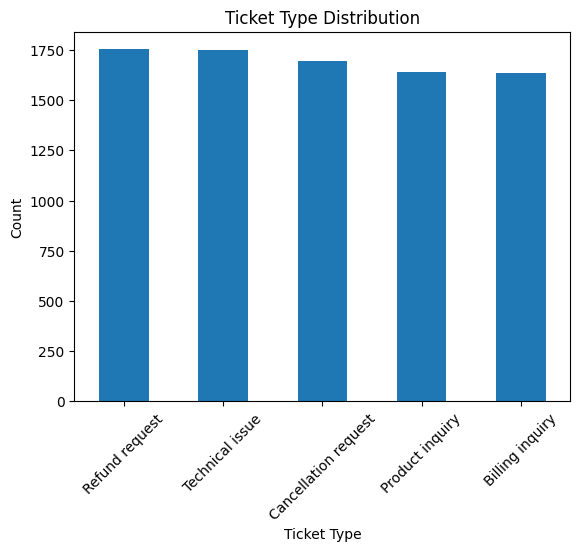

In [47]:
data_df['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.xticks(rotation=45)
plt.ylabel("Count")

In [48]:
data_df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [49]:
data_df['Ticket Subject'].unique()

<StringArray>
[           'Product setup', 'Peripheral compatibility',
          'Network problem',           'Account access',
                'Data loss',            'Payment issue',
           'Refund request',             'Battery life',
     'Installation support',             'Software bug',
           'Hardware issue',   'Product recommendation',
         'Delivery problem',            'Display issue',
     'Cancellation request',    'Product compatibility']
Length: 16, dtype: str

In [50]:
data_df['Ticket Subject'].value_counts()

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

These are like the ground truth values. Meaning we can use these ticket type to evalute the clusters

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


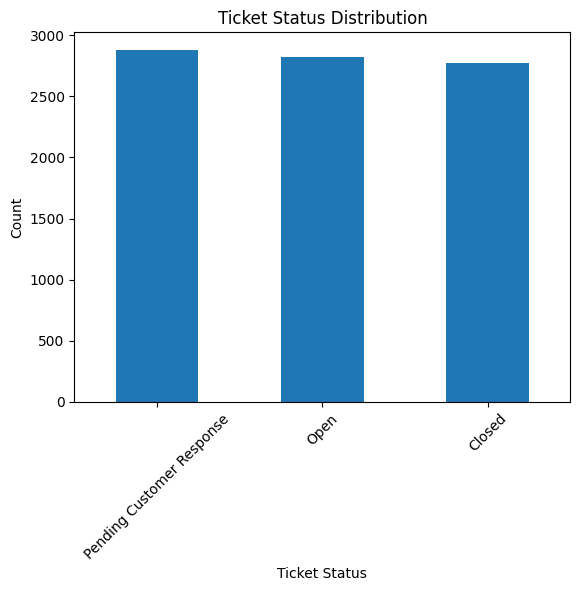

In [51]:
print(data_df['Ticket Type'].value_counts())
data_df['Ticket Status'].value_counts().plot(kind='bar')
plt.title("Ticket Status Distribution") 
plt.xlabel("Ticket Status")
plt.xticks(rotation=45) 
plt.ylabel("Count")
plt.show()  

In [52]:
data_df['Customer Age'].agg(['mean', 'max', 'min'])

mean    44.026804
max     70.000000
min     18.000000
Name: Customer Age, dtype: float64

In [53]:
data_df['Date of Purchase'].agg(['max', 'min'])

max    2021-12-30
min    2020-01-01
Name: Date of Purchase, dtype: str

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


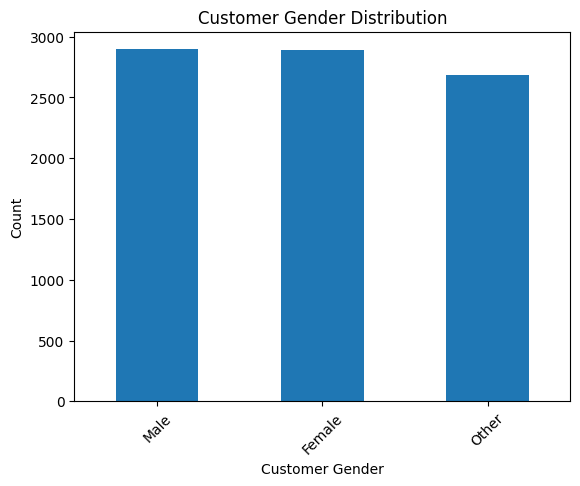

In [54]:
print(data_df['Customer Gender'].value_counts())
data_df['Customer Gender'].value_counts().plot(kind='bar')
plt.title("Customer Gender Distribution")
plt.xlabel("Customer Gender")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

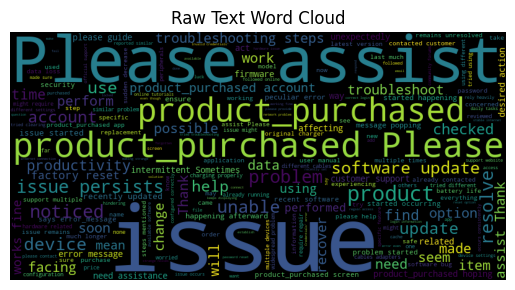

In [55]:
wordcloud = WordCloud(width=800, height=400).generate(" ".join(text_data))

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Raw Text Word Cloud")
plt.show()

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


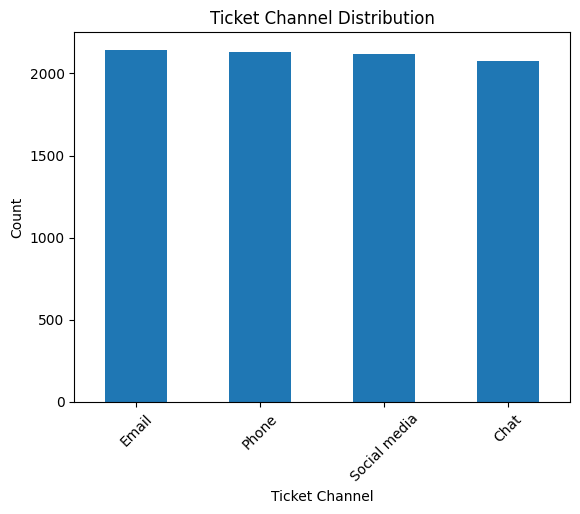

In [56]:
print(data_df['Ticket Channel'].value_counts())
data_df['Ticket Channel'].value_counts().plot(kind='bar')
plt.title("Ticket Channel Distribution")
plt.xlabel("Ticket Channel")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

In [57]:
results_list = []

for i in range(len(data_df['Ticket Description'])):
    text = data_df['Ticket Description'][i]
    matches = re.findall(r'\{.*?\}', text)
    if matches:
        filtered_matches = [m for m in matches if m != "{Product_purchased}"]
        if filtered_matches:
            results_list.append(f"Found patterns in ticket {i}: {filtered_matches}")
for line in results_list[:10]:
    print(line)


Found patterns in ticket 0: ['{product_purchased}']
Found patterns in ticket 1: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 2: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 3: ['{product_purchased}']
Found patterns in ticket 4: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 5: ['{product_purchased}', '{product_purchased}', "{product_purch I've checked for any available software updates for my {product_purchased}"]
Found patterns in ticket 6: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 7: ['{product_purchased}', '{product_purchased}']
Found patterns in ticket 8: ['{product_purchased}', '{product_purchased}', '{product_purchased}']
Found patterns in ticket 9: ['{product_purchased}']


We will have to remove these text messages so that the clusters come out to be clean

## Bivariate Analysis

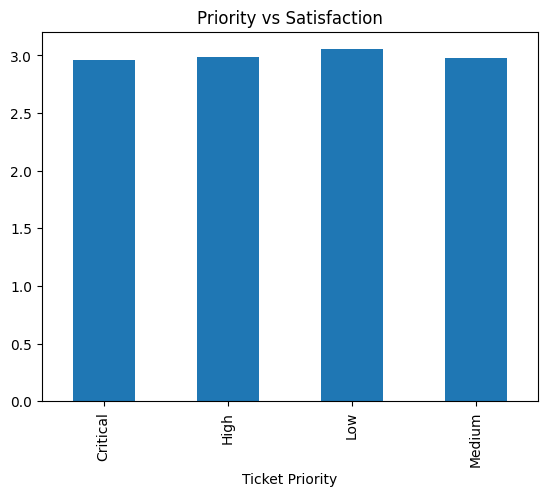

In [58]:
data_df.groupby('Ticket Priority')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Priority vs Satisfaction")
plt.show()

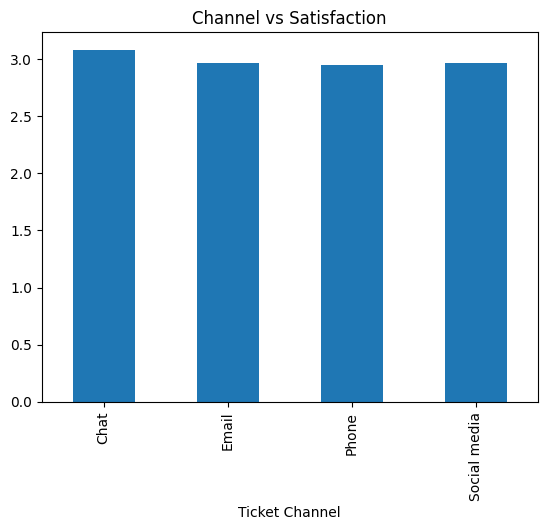

In [59]:
data_df.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().plot(kind='bar')
plt.title("Channel vs Satisfaction")
plt.show()

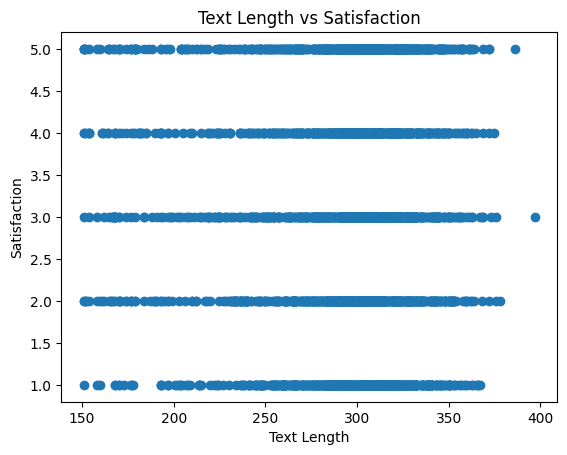

In [60]:
plt.scatter(data_df['text_length'], data_df['Customer Satisfaction Rating'])
plt.xlabel("Text Length")
plt.ylabel("Satisfaction")
plt.title("Text Length vs Satisfaction")
plt.show()

In [61]:
pd.crosstab(data_df['Ticket Type'], data_df['Ticket Priority'])


Ticket Priority,Critical,High,Low,Medium
Ticket Type,,,,
Billing inquiry,420,382,398,434
Cancellation request,423,398,414,460
Product inquiry,403,399,398,441
Refund request,444,448,440,420
Technical issue,439,458,413,437


<Axes: xlabel='Ticket Type'>

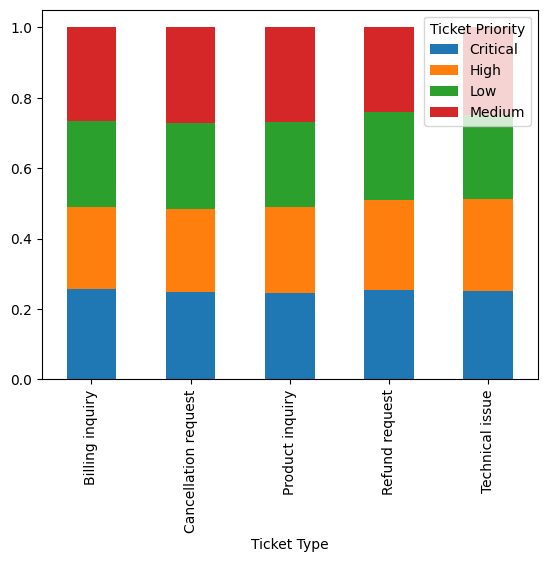

In [62]:
pd.crosstab(data_df['Ticket Type'], data_df['Ticket Priority'], normalize='index').plot(kind='bar', stacked=True)

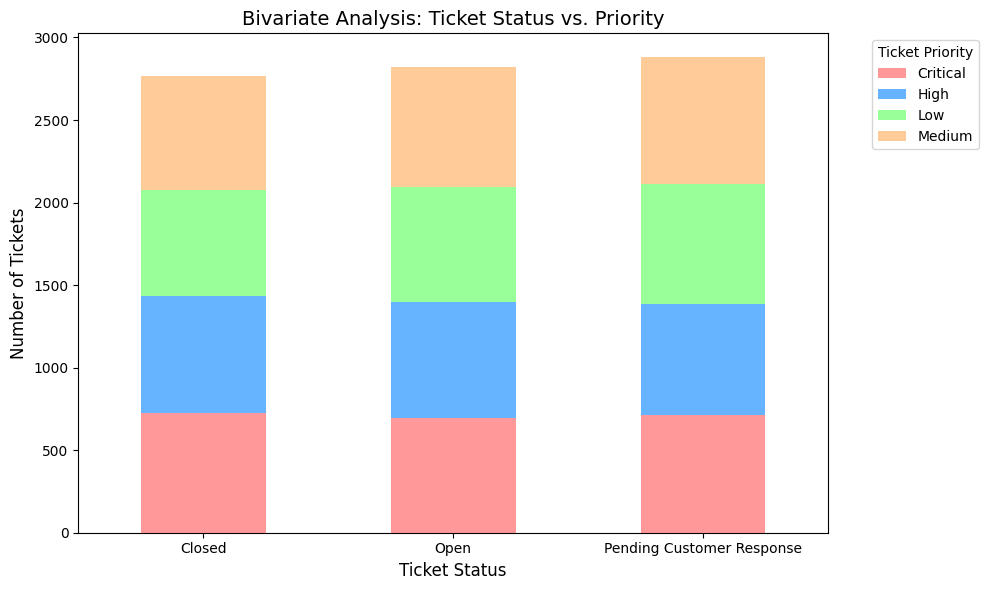

In [63]:
status_priority_map = pd.crosstab(data_df['Ticket Status'], data_df['Ticket Priority'])
status_priority_map.plot(kind='bar', 
                         stacked=True, 
                         figsize=(10, 6), 
                         color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title("Bivariate Analysis: Ticket Status vs. Priority", fontsize=14)
plt.xlabel("Ticket Status", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.legend(title="Ticket Priority", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

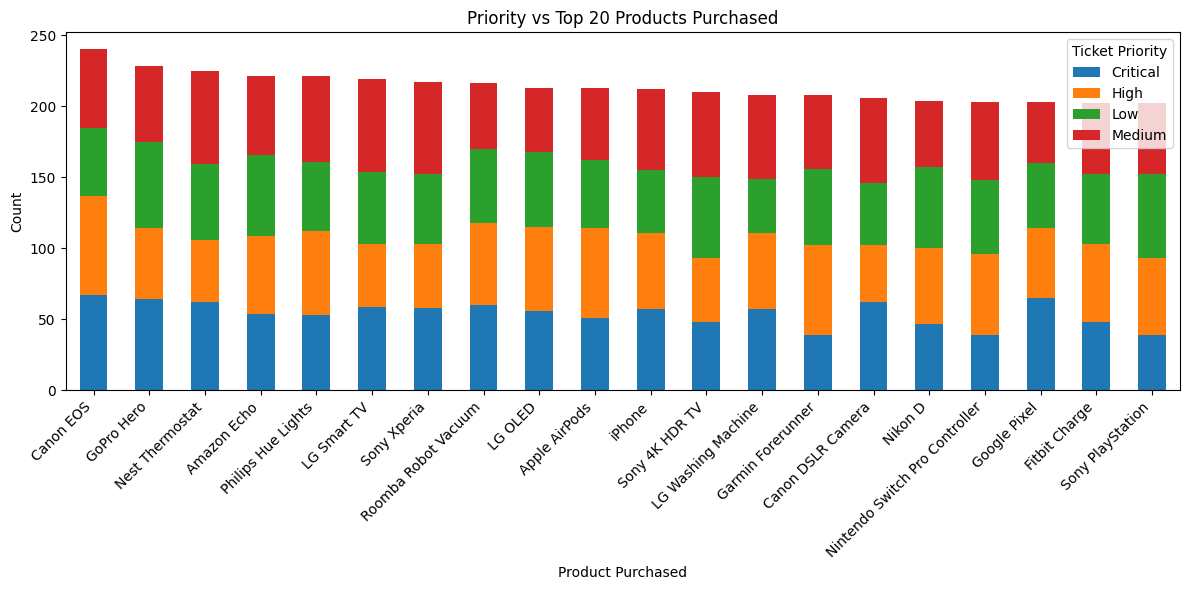

In [64]:
top_20_products = data_df['Product Purchased'].value_counts().nlargest(20).index
filtered_df = data_df[data_df['Product Purchased'].isin(top_20_products)]
plot_data = filtered_df.groupby(['Product Purchased', 'Ticket Priority']).size().unstack()
plot_data['Total'] = plot_data.sum(axis=1)
plot_data = plot_data.sort_values('Total', ascending=False).drop(columns='Total')

plot_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Priority vs Top 20 Products Purchased")
plt.xlabel("Product Purchased")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ticket Priority')
plt.tight_layout()
plt.show()

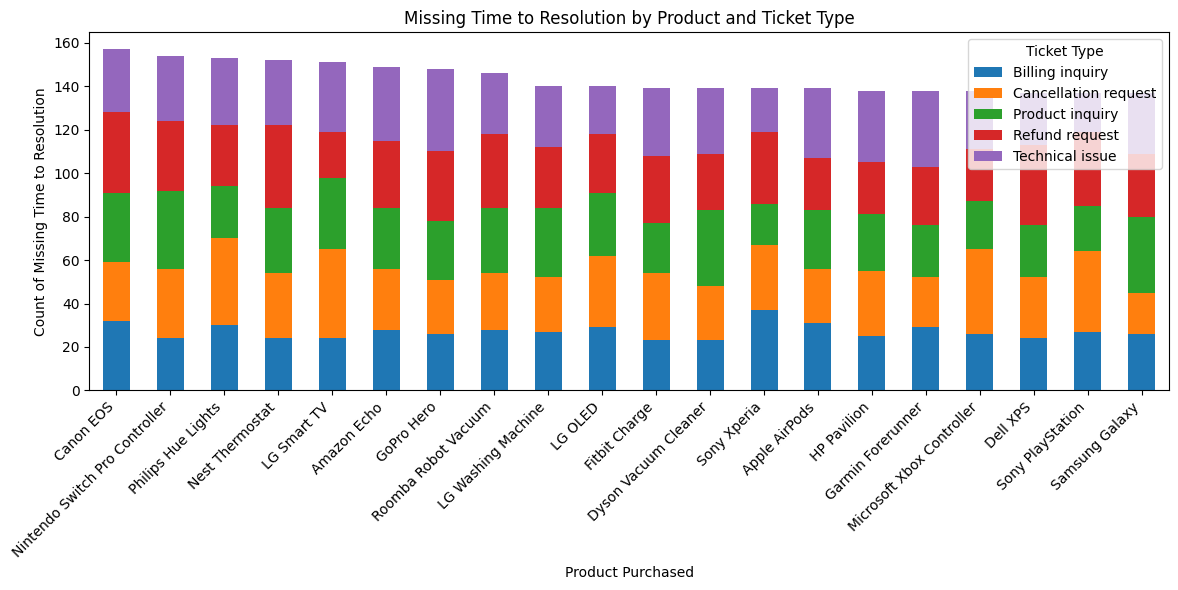

In [65]:
missingdata = data_df['Time to Resolution'].isnull()
missingplotdata_df = data_df[missingdata].groupby(['Product Purchased', 'Ticket Type']).size().unstack()
missingplotdata_df = missingplotdata_df.assign(Total=missingplotdata_df.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total').head(20)
missingplotdata_df.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Missing Time to Resolution by Product and Ticket Type")
plt.xlabel("Product Purchased")
plt.ylabel("Count of Missing Time to Resolution")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

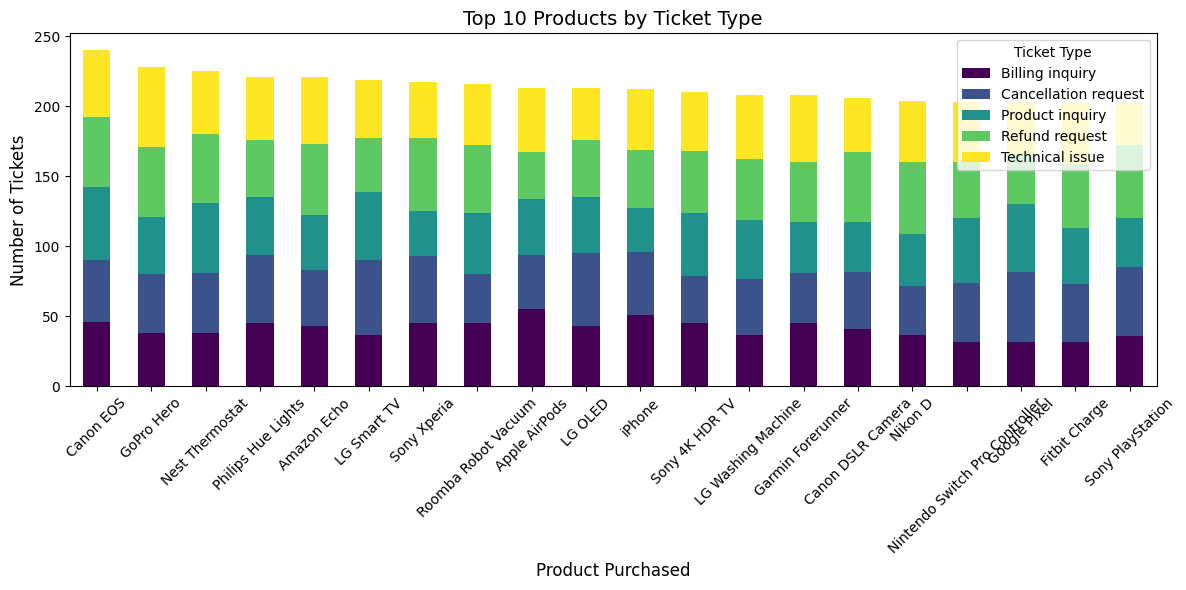

In [66]:
plot_data = data_df.groupby(['Product Purchased', 'Ticket Type']).size().unstack()
plot_data = plot_data.assign(Total=plot_data.sum(axis=1)).sort_values(by='Total', ascending=False).drop(columns='Total').head(20)
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title("Top 10 Products by Ticket Type", fontsize=14)
plt.xlabel("Product Purchased", fontsize=12)
plt.ylabel("Number of Tickets", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Ticket Type")
plt.tight_layout()

## Multivariant Analysis

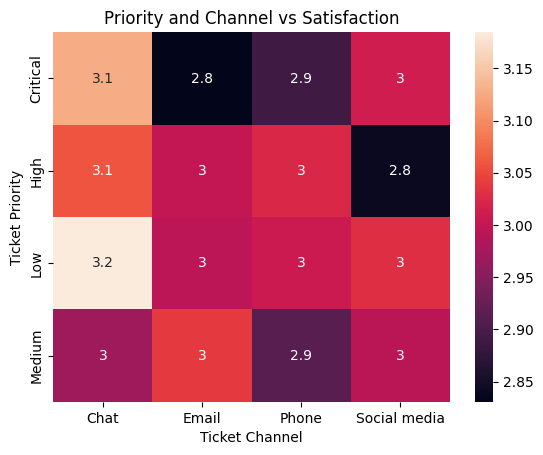

In [67]:
pivot = data_df.pivot_table(values='Customer Satisfaction Rating',index='Ticket Priority',columns='Ticket Channel',aggfunc='mean')
sns.heatmap(pivot, annot=True)
plt.title("Priority and Channel vs Satisfaction")
plt.show()

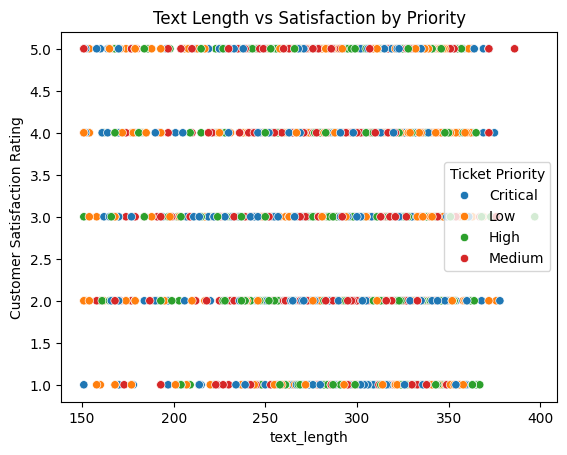

In [68]:
sns.scatterplot(data=data_df,x='text_length',y='Customer Satisfaction Rating',hue='Ticket Priority')
plt.title("Text Length vs Satisfaction by Priority")
plt.show()